In [2]:
print("Hello, E-comerce Analtytics!")

Hello, E-comerce Analtytics!


In [7]:
import os

os.listdir('../data')

['archive',
 'olist_customers_dataset.csv',
 'olist_geolocation_dataset.csv',
 'olist_orders_dataset.csv',
 'olist_order_items_dataset.csv',
 'olist_order_payments_dataset.csv',
 'olist_order_reviews_dataset.csv',
 'olist_products_dataset.csv',
 'olist_sellers_dataset.csv',
 'product_category_name_translation.csv']

In [6]:
import pandas as pd

customers = pd.read_csv('../data/olist_customers_dataset.csv')
customers.head()

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP


In [8]:
import pandas as pd

orders = pd.read_csv('../data/olist_orders_dataset.csv')
items = pd.read_csv('../data/olist_order_items_dataset.csv')
payments = pd.read_csv('../data/olist_order_payments_dataset.csv')
products = pd.read_csv('../data/olist_products_dataset.csv')
sellers = pd.read_csv('../data/olist_sellers_dataset.csv')
reviews = pd.read_csv('../data/olist_order_reviews_dataset.csv')
orders.head()
items.head()
payments.head()
products.head()
sellers.head()
reviews.head()

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,NaN,NaN,2018-01-18 00:00:00,2018-01-18 21:46:59
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,NaN,NaN,2018-03-10 00:00:00,2018-03-11 03:05:13
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,NaN,NaN,2018-02-17 00:00:00,2018-02-18 14:36:24
3,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,5,NaN,Recebi bem antes do prazo estipulado.,2017-04-21 00:00:00,2017-04-21 22:02:06
4,f7c4243c7fe1938f181bec41a392bdeb,8e6bfb81e283fa7e4f11123a3fb894f1,5,NaN,Parabéns lojas lannister adorei comprar pela I...,2018-03-01 00:00:00,2018-03-02 10:26:53


In [9]:
print("Customers:", customers.shape)
print("Orders:", orders.shape)
print("Items:", items.shape)
print("Payments:", payments.shape)
print("Products", products.shape)
print("Sellers:", sellers.shape)
print("Reviews:", reviews.shape)


Customers: (99441, 5)
Orders: (99441, 8)
Items: (112650, 7)
Payments: (103886, 5)
Products (32951, 9)
Sellers: (3095, 4)
Reviews: (99224, 7)


In [10]:
customers.info()

<class 'pandas.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   customer_id               99441 non-null  str  
 1   customer_unique_id        99441 non-null  str  
 2   customer_zip_code_prefix  99441 non-null  int64
 3   customer_city             99441 non-null  str  
 4   customer_state            99441 non-null  str  
dtypes: int64(1), str(4)
memory usage: 11.0 MB


In [8]:
customers.describe()

,customer_zip_code_prefix
count,99441.000000
mean,35137.474583
std,29797.938996
min,1003.000000
25%,11347.000000
50%,24416.000000
75%,58900.000000
max,99990.000000


In [9]:
customers.isnull().sum()

customer_id                 0
customer_unique_id          0
customer_zip_code_prefix    0
customer_city               0
customer_state              0
dtype: int64

In [10]:
orders.isnull().sum()

order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64

In [11]:
items.isnull().sum()

order_id               0
order_item_id          0
product_id             0
seller_id              0
shipping_limit_date    0
price                  0
freight_value          0
dtype: int64

In [12]:
payments.isnull().sum()

order_id                0
payment_sequential      0
payment_type            0
payment_installments    0
payment_value           0
dtype: int64

In [7]:
products.isnull().sum()

product_id                      0
product_category_name         610
product_name_lenght           610
product_description_lenght    610
product_photos_qty            610
product_weight_g                2
product_length_cm               2
product_height_cm               2
product_width_cm                2
dtype: int64

In [21]:
products["product_category_name"].fillna("Unknown", inplace=True)

products["product_name_lenght"].fillna(products["product_name_lenght"].median(), inplace=True)

products["product_description_lenght"].fillna(products["product_description_lenght"].median(), inplace=True)

products["product_photos_qty"].fillna(products["product_photos_qty"].median(), inplace=True)

products["product_weight_g"].fillna(products["product_weight_g"].median(), inplace=True)

products["product_length_cm"].fillna(products["product_length_cm"].median(), inplace=True)

products["product_height_cm"].fillna(products["product_height_cm"].median(), inplace=True)

products["product_width_cm"].fillna(products["product_width_cm"].median(), inplace=True)

C:\Users\hp\AppData\Local\Temp\ipykernel_9044\996387112.py:1: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  products["product_category_name"].fillna("Unknown", inplace=True)
C:\Users\hp\AppData\Local\Temp\ipykernel_9044\996387112.py:3: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained ass

0        14.0
1        20.0
2        15.0
3        26.0
4        13.0
         ... 
32946    40.0
32947    16.0
32948    27.0
32949    20.0
32950     7.0
Name: product_width_cm, Length: 32951, dtype: float64

In [8]:
sellers.isnull().sum()

seller_id                 0
seller_zip_code_prefix    0
seller_city               0
seller_state              0
dtype: int64

In [9]:
reviews.isnull().sum()

review_id                      0
order_id                       0
review_score                   0
review_comment_title       87656
review_comment_message     58247
review_creation_date           0
review_answer_timestamp        0
dtype: int64

In [22]:
reviews["review_comment_title"].fillna("No Title", inplace=True)

reviews["review_comment_message"].fillna("No Comment", inplace=True)

C:\Users\hp\AppData\Local\Temp\ipykernel_9044\2631309255.py:1: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  reviews["review_comment_title"].fillna("No Title", inplace=True)
C:\Users\hp\AppData\Local\Temp\ipykernel_9044\2631309255.py:3: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained as

0                                               No Comment
1                                               No Comment
2                                               No Comment
3                    Recebi bem antes do prazo estipulado.
4        Parabéns lojas lannister adorei comprar pela I...
                               ...                        
99219                                           No Comment
99220                                           No Comment
99221    Excelente mochila, entrega super rápida. Super...
99222                                           No Comment
99223    meu produto chegou e ja tenho que devolver, po...
Name: review_comment_message, Length: 99224, dtype: str

In [23]:
print("Customers:", customers.duplicated().sum())
print("Orders:", orders.duplicated().sum())
print("Items:", items.duplicated().sum())
print("Payments:", payments.duplicated().sum())
print("Products:", products.duplicated().sum())
print("Sellers:", sellers.duplicated().sum())
print("Reviews:", reviews.duplicated().sum())

Customers: 0
Orders: 0
Items: 0
Payments: 0
Products: 0
Sellers: 0
Reviews: 0


In [24]:
orders.describe()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
count,99441,99441,99441,99441,99281,97658,96476,99441
unique,99441,99441,8,98875,90733,81018,95664,459
top,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2018-03-31 15:08:21,2018-02-27 04:31:10,2018-05-09 15:48:00,2018-05-14 20:02:44,2017-12-20 00:00:00
freq,1,1,96478,3,9,47,3,522


In [25]:
payments.describe()

,payment_sequential,payment_installments,payment_value
count,103886.000000,103886.000000,103886.000000
mean,1.092679,2.853349,154.100380
std,0.706584,2.687051,217.494064
min,1.000000,0.000000,0.000000
25%,1.000000,1.000000,56.790000
50%,1.000000,1.000000,100.000000
75%,1.000000,4.000000,171.837500
max,29.000000,24.000000,13664.080000


In [26]:
products.describe(include="all")

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
count,32951,32341,32341.000000,32341.000000,32341.000000,32949.000000,32949.000000,32949.000000,32949.000000
unique,32951,73,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,1e9e8ef04dbcff4541ed26657ea517e5,cama_mesa_banho,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,1,3029,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,48.476949,771.495285,2.188986,2276.472488,30.815078,16.937661,23.196728
std,NaN,NaN,10.245741,635.115225,1.736766,4282.038731,16.914458,13.637554,12.079047
min,NaN,NaN,5.000000,4.000000,1.000000,0.000000,7.000000,2.000000,6.000000
25%,NaN,NaN,42.000000,339.000000,1.000000,300.000000,18.000000,8.000000,15.000000
50%,NaN,NaN,51.000000,595.000000,1.000000,700.000000,25.000000,13.000000,20.000000
75%,NaN,NaN,57.000000,972.000000,3.000000,1900.000000,38.000000,21.000000,30.000000


In [27]:
print("unique Customers:", customers["customer_unique_id"].nunique())
print("Unique Orders:", orders["order_id"].nunique())
print("Unique Sellers:", sellers["seller_id"].nunique())
print("Unique Products:", products["product_id"].nunique())

unique Customers: 96096
Unique Orders: 99441
Unique Sellers: 3095
Unique Products: 32951


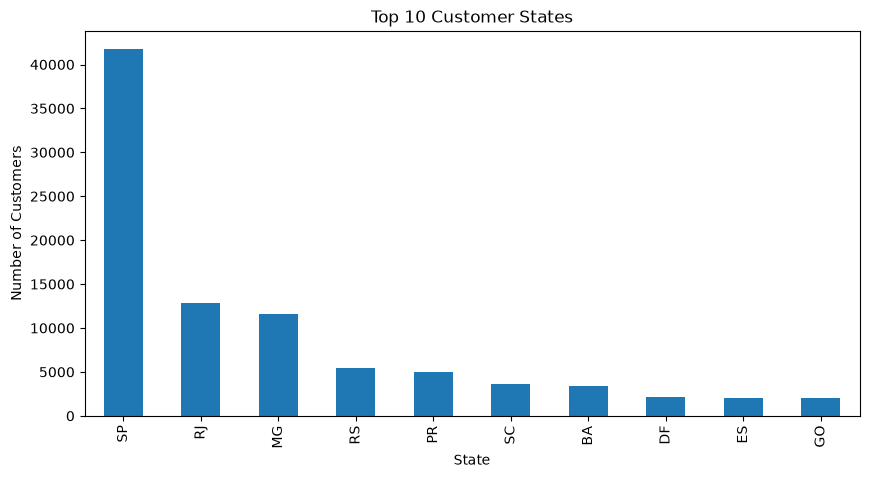

In [28]:
import matplotlib.pyplot as plt

customers["customer_state"].value_counts().head(10).plot(kind="bar",figsize=(10,5))
plt.title("Top 10 Customer States")
plt.xlabel("State")
plt.ylabel("Number of Customers")
plt.show()

In [29]:
customers["customer_state"].value_counts().head(10)

customer_state
SP    41746
RJ    12852
MG    11635
RS     5466
PR     5045
SC     3637
BA     3380
DF     2140
ES     2033
GO     2020
Name: count, dtype: int64

In [30]:
payments["payment_type"].value_counts()

payment_type
credit_card    76795
boleto         19784
voucher         5775
debit_card      1529
not_defined        3
Name: count, dtype: int64

In [31]:
payments["payment_value"].mean()

np.float64(154.10038041699556)

In [32]:
print("Highest Payment:", payments["payment_value"].max())
print("Lowest Payment:", payments["payment_value"].min())

Highest Payment: 13664.08
Lowest Payment: 0.0


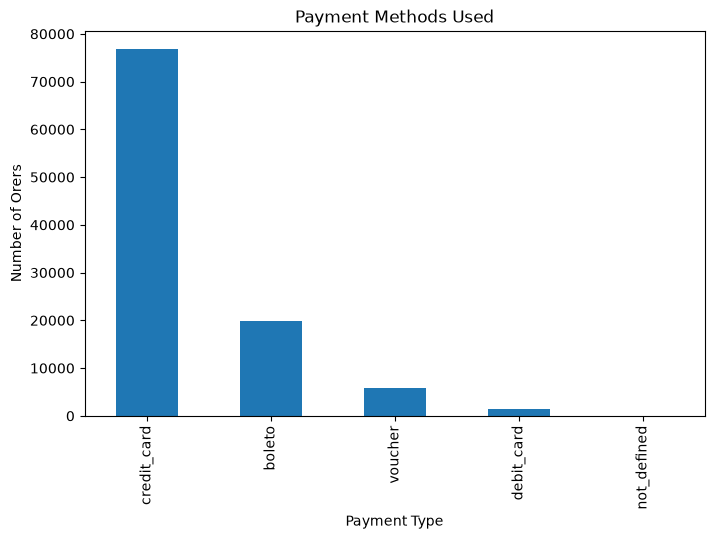

In [33]:
import matplotlib.pyplot as plt

payments["payment_type"].value_counts().plot(kind="bar",figsize=(8,5))
plt.title("Payment Methods Used")
plt.xlabel("Payment Type")
plt.ylabel("Number of Orers")
plt.show()

In [34]:
orders_payments = orders.merge(
    payments,
    on="order_id",
    how="inner"
)
orders_payments.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,payment_sequential,payment_type,payment_installments,payment_value
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,1,credit_card,1,18.12
1,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,3,voucher,1,2.00
2,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,2,voucher,1,18.59
3,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,1,boleto,1,141.46
4,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,1,credit_card,3,179.12


In [35]:
orders_payments.shape

(103886, 12)

In [36]:
total_revenue = orders_payments["payment_value"].sum()
print(f"Total Revenue: R$ {total_revenue:,.2f}")


Total Revenue: R$ 16,008,872.12


In [37]:
average_order = orders_payments["payment_value"].mean()
print(f"Average Order Value: R${average_order:.2f}")

Average Order Value: R$154.10


In [38]:
orders_payments.sort_values(by="payment_value", ascending=False).head(10)

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,payment_sequential,payment_type,payment_installments,payment_value
13958,03caa2c082116e1d31e67e9ae3700499,1617b1357756262bfa56ab541c47bc16,delivered,2017-09-29 15:24:52,2017-10-02 15:28:20,2017-10-10 15:43:17,2017-10-17 18:22:29,2017-10-23 00:00:00,1,credit_card,1,13664.08
69543,736e1922ae60d0d6a89247b851902527,ec5b2ba62e574342386871631fafd3fc,delivered,2018-07-15 14:49:44,2018-07-17 04:31:36,2018-07-20 13:09:00,2018-07-26 22:03:06,2018-08-02 00:00:00,1,boleto,1,7274.88
23138,0812eb902a67711a1cb742b3cdaa65ae,c6e2731c5b391845f6800c97401a43a9,delivered,2017-02-12 20:37:36,2017-02-12 20:45:12,2017-02-16 09:23:13,2017-03-03 14:23:18,2017-03-09 00:00:00,1,credit_card,8,6929.31
29628,fefacc66af859508bf1a7934eab1e97f,f48d464a0baaea338cb25f816991ab1f,delivered,2018-07-25 18:10:17,2018-07-27 04:05:13,2018-08-03 14:42:00,2018-08-15 14:57:50,2018-08-10 00:00:00,1,boleto,1,6922.21
3665,f5136e38d1a14a4dbd87dff67da82701,3fd6777bbce08a352fddd04e4a7cc8f6,delivered,2017-05-24 18:14:34,2017-05-26 02:45:17,2017-05-26 11:20:47,2017-06-05 17:09:48,2017-06-28 00:00:00,1,boleto,1,6726.66
33833,2cc9089445046817a7539d90805e6e5a,05455dfa7cd02f13d132aa7a6a9729c6,delivered,2017-11-24 11:03:35,2017-11-28 12:55:46,2017-12-06 11:52:14,2017-12-13 12:16:02,2017-12-22 00:00:00,1,boleto,1,6081.54
55774,a96610ab360d42a2e5335a3998b4718a,df55c14d1476a9a3467f131269c2477f,delivered,2017-04-01 15:58:40,2017-04-03 13:25:18,2017-04-11 15:10:34,2017-04-17 11:04:45,2017-05-02 00:00:00,1,credit_card,10,4950.34
43005,b4c4b76c642808cbe472a32b86cddc95,e0a2412720e9ea4f26c1ac985f6a7358,canceled,2018-07-12 12:08:36,2018-07-12 12:25:53,NaN,NaN,2018-08-01 00:00:00,1,credit_card,5,4809.44
42208,199af31afc78c699f0dbf71fb178d4d4,24bbf5fd2f2e1b359ee7de94defc4a15,delivered,2017-04-18 18:50:13,2017-04-19 15:50:15,2017-04-25 13:39:59,2017-05-07 10:42:39,2017-05-15 00:00:00,1,credit_card,8,4764.34
42224,8dbc85d1447242f3b127dda390d56e19,3d979689f636322c62418b6346b1c6d2,delivered,2018-06-22 12:23:19,2018-06-22 12:36:36,2018-06-22 13:00:00,2018-07-06 01:08:30,2018-07-17 00:00:00,1,credit_card,8,4681.78


In [39]:
print(customers.dtypes)
print("\n")

print(orders.dtypes)
print("\n")

print(items.dtypes)
print("\n")

print(payments.dtypes)
print("\n")

print(products.dtypes)
print("\n")

print(sellers.dtypes)
print("\n")

print(reviews.dtypes)

customer_id                   str
customer_unique_id            str
customer_zip_code_prefix    int64
customer_city                 str
customer_state                str
dtype: object


order_id                         str
customer_id                      str
order_status                     str
order_purchase_timestamp         str
order_approved_at                str
order_delivered_carrier_date     str
order_delivered_customer_date    str
order_estimated_delivery_date    str
dtype: object


order_id                   str
order_item_id            int64
product_id                 str
seller_id                  str
shipping_limit_date        str
price                  float64
freight_value          float64
dtype: object


order_id                    str
payment_sequential        int64
payment_type                str
payment_installments      int64
payment_value           float64
dtype: object


product_id                        str
product_category_name             str
product_name_leng

In [40]:
orders["order_purchase_timestamp"] = pd.to_datetime(orders["order_purchase_timestamp"])
orders["order_approved_at"] = pd.to_datetime(orders["order_approved_at"])
orders["order_delivered_carrier_date"] = pd.to_datetime(orders["order_delivered_carrier_date"])
orders["order_delivered_customer_date"] = pd.to_datetime(orders["order_delivered_customer_date"])
orders["order_estimated_delivery_date"] = pd.to_datetime(orders["order_estimated_delivery_date"])

reviews["review_creation_date"] = pd.to_datetime(reviews["review_creation_date"])
reviews["review_answer_timestamp"] = pd.to_datetime(reviews["review_answer_timestamp"])

In [41]:
orders.dtypes

order_id                                    str
customer_id                                 str
order_status                                str
order_purchase_timestamp         datetime64[us]
order_approved_at                datetime64[us]
order_delivered_carrier_date     datetime64[us]
order_delivered_customer_date    datetime64[us]
order_estimated_delivery_date    datetime64[us]
dtype: object

In [42]:
master_df = orders.merge(customers, on="customer_id", how="left")

master_df = master_df.merge(items, on="order_id", how="left")

master_df = master_df.merge(products, on="product_id", how="left")

master_df = master_df.merge(payments, on="order_id", how="left")

master_df = master_df.merge(sellers, on="seller_id", how="left")

master_df = master_df.merge(reviews, on="order_id", how="left")

In [43]:
master_df.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,...,payment_value,seller_zip_code_prefix,seller_city,seller_state,review_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,3149,...,18.12,9350.0,maua,SP,a54f0611adc9ed256b57ede6b6eb5114,4.0,NaN,"Não testei o produto ainda, mas ele veio corre...",2017-10-11,2017-10-12 03:43:48
1,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,3149,...,2.00,9350.0,maua,SP,a54f0611adc9ed256b57ede6b6eb5114,4.0,NaN,"Não testei o produto ainda, mas ele veio corre...",2017-10-11,2017-10-12 03:43:48
2,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,3149,...,18.59,9350.0,maua,SP,a54f0611adc9ed256b57ede6b6eb5114,4.0,NaN,"Não testei o produto ainda, mas ele veio corre...",2017-10-11,2017-10-12 03:43:48
3,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,af07308b275d755c9edb36a90c618231,47813,...,141.46,31570.0,belo horizonte,SP,8d5266042046a06655c8db133d120ba5,4.0,Muito boa a loja,Muito bom o produto.,2018-08-08,2018-08-08 18:37:50
4,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,3a653a41f6f9fc3d2a113cf8398680e8,75265,...,179.12,14840.0,guariba,SP,e73b67b67587f7644d5bd1a52deb1b01,5.0,NaN,NaN,2018-08-18,2018-08-22 19:07:58


In [44]:
master_df.shape

(119143, 39)

In [45]:
master_df.columns

Index(['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp',
       'order_approved_at', 'order_delivered_carrier_date',
       'order_delivered_customer_date', 'order_estimated_delivery_date',
       'customer_unique_id', 'customer_zip_code_prefix', 'customer_city',
       'customer_state', 'order_item_id', 'product_id', 'seller_id',
       'shipping_limit_date', 'price', 'freight_value',
       'product_category_name', 'product_name_lenght',
       'product_description_lenght', 'product_photos_qty', 'product_weight_g',
       'product_length_cm', 'product_height_cm', 'product_width_cm',
       'payment_sequential', 'payment_type', 'payment_installments',
       'payment_value', 'seller_zip_code_prefix', 'seller_city',
       'seller_state', 'review_id', 'review_score', 'review_comment_title',
       'review_comment_message', 'review_creation_date',
       'review_answer_timestamp'],
      dtype='str')

In [46]:
master_df.describe()

,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_zip_code_prefix,order_item_id,price,freight_value,product_name_lenght,...,product_length_cm,product_height_cm,product_width_cm,payment_sequential,payment_installments,payment_value,seller_zip_code_prefix,review_score,review_creation_date,review_answer_timestamp
count,119143,118966,117057,115722,119143,119143.000000,118310.000000,118310.000000,118310.000000,116601.000000,...,118290.000000,118290.000000,118290.000000,119140.000000,119140.000000,119140.000000,118310.000000,118146.000000,118146,118146
mean,2017-12-29 18:36:13.115760,2017-12-30 04:49:18.425726,2018-01-03 08:24:34.395525,2018-01-12 20:55:38.199616,2018-01-22 15:21:10.241642,35033.451298,1.196543,120.646603,20.032387,48.767498,...,30.265145,16.619706,23.074799,1.094737,2.941246,172.735135,24442.410413,4.015582,2018-01-11 13:17:50.103093,2018-01-14 17:00:35.769302
min,2016-09-04 21:15:19,2016-09-15 12:16:38,2016-10-08 10:34:01,2016-10-11 13:46:32,2016-09-30 00:00:00,1003.000000,1.000000,0.850000,0.000000,5.000000,...,7.000000,2.000000,6.000000,1.000000,0.000000,0.000000,1001.000000,1.000000,2016-10-02 00:00:00,2016-10-07 18:32:28
25%,2017-09-10 20:15:46,2017-09-11 15:50:48.500000,2017-09-14 19:52:12,2017-09-22 21:54:31.250000,2017-10-02 00:00:00,11250.000000,1.000000,39.900000,13.080000,42.000000,...,18.000000,8.000000,15.000000,1.000000,1.000000,60.850000,6429.000000,4.000000,2017-09-22 00:00:00,2017-09-25 11:15:40.750000
50%,2018-01-17 11:59:12,2018-01-17 16:49:49,2018-01-23 17:03:08,2018-02-01 03:17:55,2018-02-14 00:00:00,24240.000000,1.000000,74.900000,16.280000,52.000000,...,25.000000,13.000000,20.000000,1.000000,2.000000,108.160000,13660.000000,5.000000,2018-02-01 00:00:00,2018-02-03 12:04:23
75%,2018-05-03 13:18:30,2018-05-03 16:56:53,2018-05-07 14:57:00,2018-05-15 00:08:31.500000,2018-05-25 00:00:00,58475.000000,1.000000,134.900000,21.180000,57.000000,...,38.000000,20.000000,30.000000,1.000000,4.000000,189.240000,27972.000000,5.000000,2018-05-15 00:00:00,2018-05-17 10:48:59
max,2018-10-17 17:30:18,2018-09-03 17:40:06,2018-09-11 19:48:28,2018-10-17 13:22:46,2018-11-12 00:00:00,99990.000000,21.000000,6735.000000,409.680000,76.000000,...,105.000000,105.000000,118.000000,29.000000,24.000000,13664.080000,99730.000000,5.000000,2018-08-31 00:00:00,2018-10-29 12:27:35
std,NaN,NaN,NaN,NaN,NaN,29823.198969,0.699489,184.109691,15.836850,10.033540,...,16.189367,13.453584,11.749139,0.730141,2.777848,267.776077,27573.004511,1.400436,NaN,NaN


In [47]:
master_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 119143 entries, 0 to 119142
Data columns (total 39 columns):
 #   Column                         Non-Null Count   Dtype         
---  ------                         --------------   -----         
 0   order_id                       119143 non-null  str           
 1   customer_id                    119143 non-null  str           
 2   order_status                   119143 non-null  str           
 3   order_purchase_timestamp       119143 non-null  datetime64[us]
 4   order_approved_at              118966 non-null  datetime64[us]
 5   order_delivered_carrier_date   117057 non-null  datetime64[us]
 6   order_delivered_customer_date  115722 non-null  datetime64[us]
 7   order_estimated_delivery_date  119143 non-null  datetime64[us]
 8   customer_unique_id             119143 non-null  str           
 9   customer_zip_code_prefix       119143 non-null  int64         
 10  customer_city                  119143 non-null  str           
 11  customer_st

In [48]:
print("Total Sales: R$", master_df["payment_value"].sum())

Total Sales: R$ 20579664.009999998


In [49]:
print("Average Order Value: R$", round(master_df["payment_value"].mean(), 2) )

Average Order Value: R$ 172.74


In [50]:
master_df["payment_type"].value_counts()

payment_type
credit_card    87776
boleto         23190
voucher         6465
debit_card      1706
not_defined        3
Name: count, dtype: int64

In [51]:
master_df["customer_state"].value_counts().head(10)

customer_state
SP    50265
RJ    15518
MG    13819
RS     6573
PR     6043
SC     4345
BA     4091
DF     2516
GO     2466
ES     2360
Name: count, dtype: int64

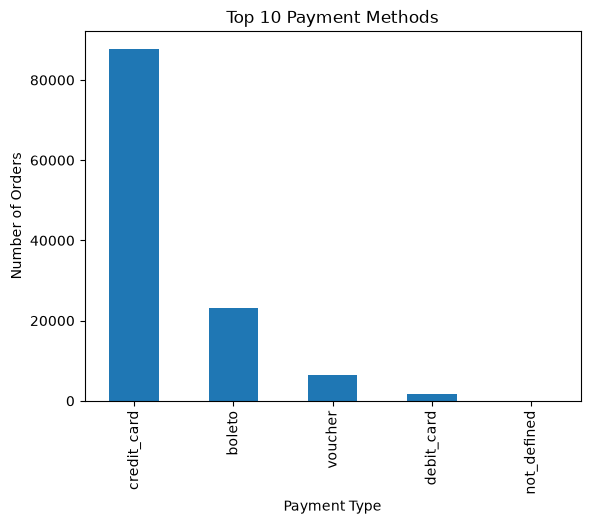

In [52]:
master_df["payment_type"].value_counts().head(10).plot(kind="bar")
plt.title("Top 10 Payment Methods")
plt.xlabel("Payment Type")
plt.ylabel("Number of Orders")

plt.show()

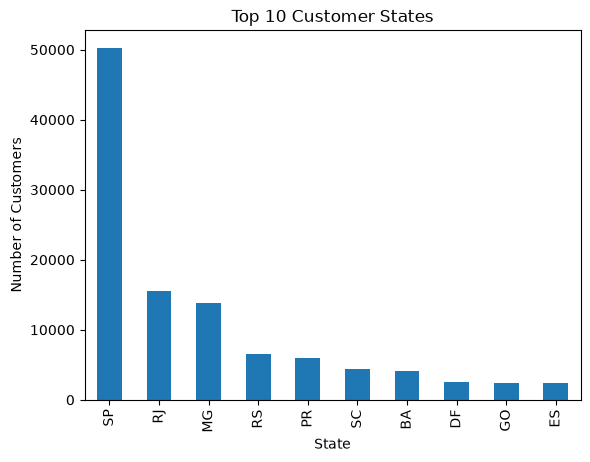

In [53]:
master_df["customer_state"].value_counts().head(10).plot(kind="bar")

plt.title("Top 10 Customer States")
plt.xlabel("State")
plt.ylabel("Number of Customers")

plt.show()

In [54]:
total_revenue = master_df["payment_value"].sum()

print(f"Total Revenue: R$ {total_revenue:,.2f}")

Total Revenue: R$ 20,579,664.01


In [55]:
average_order = master_df["payment_value"].mean()

print(f"Average Order Value: R$ {average_order:.2f}")

Average Order Value: R$ 172.74


In [56]:
payment_revenue = (
    master_df.groupby("payment_type")["payment_value"]
    .sum()
    .sort_values(ascending=False)
)

print(payment_revenue)

payment_type
credit_card    15775450.54
boleto          4110920.74
voucher          435917.84
debit_card       257374.89
not_defined           0.00
Name: payment_value, dtype: float64


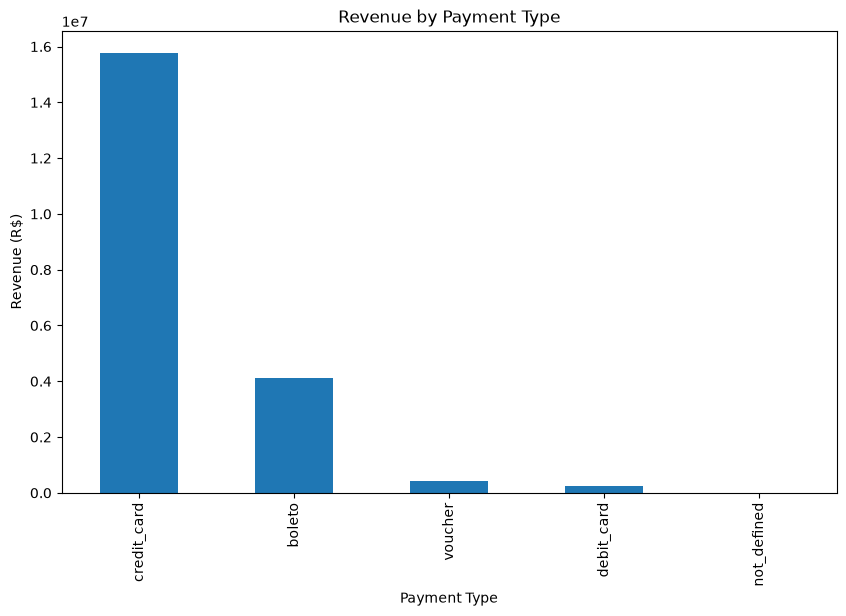

In [57]:
payment_revenue.plot(kind="bar", figsize=(10,6))

plt.title("Revenue by Payment Type")
plt.xlabel("Payment Type")
plt.ylabel("Revenue (R$)")
plt.show()

In [58]:
state_revenue = (
    master_df.groupby("customer_state")["payment_value"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

print(state_revenue)

customer_state
SP    7726078.35
RJ    2795615.67
MG    2351221.09
RS    1160175.66
PR    1079795.49
BA     805070.98
SC     801276.45
GO     520481.65
DF     438095.32
ES     408611.64
Name: payment_value, dtype: float64


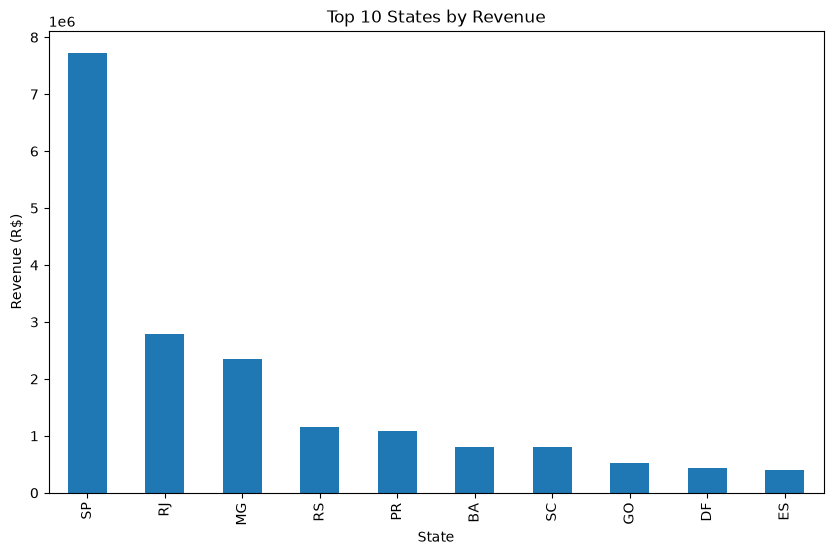

In [59]:
state_revenue.plot(kind="bar", figsize=(10,6))

plt.title("Top 10 States by Revenue")
plt.xlabel("State")
plt.ylabel("Revenue (R$)")
plt.show()

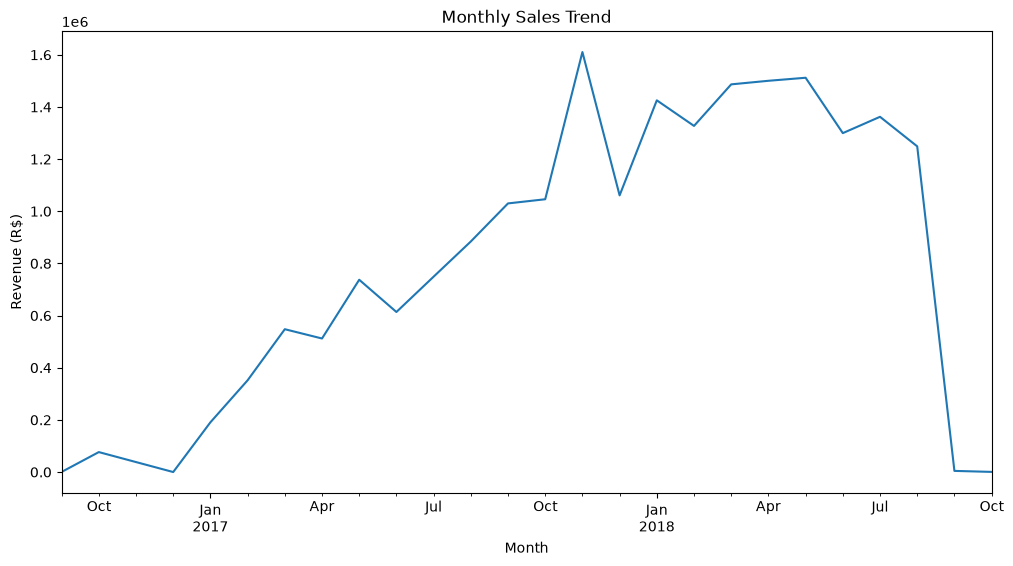

In [60]:
master_df["year_month"] = master_df["order_purchase_timestamp"].dt.to_period("M")

monthly_sales = (
    master_df.groupby("year_month")["payment_value"]
    .sum()
)

monthly_sales.plot(figsize=(12,6))

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Revenue (R$)")
plt.show()

In [61]:
import duckdb

con = duckdb.connect("../data/ecommerce.duckdb")

In [62]:
con.register("customers_df", customers)
con.register("orders_df", orders)
con.register("items_df", items)
con.register("payments_df", payments)
con.register("products_df", products)
con.register("sellers_df", sellers)
con.register("reviews_df", reviews)

In [63]:
con.execute("CREATE OR REPLACE TABLE customers AS SELECT * FROM customers_df")
con.execute("CREATE OR REPLACE TABLE orders AS SELECT * FROM orders_df")
con.execute("CREATE OR REPLACE TABLE order_items AS SELECT * FROM items_df")
con.execute("CREATE OR REPLACE TABLE payments AS SELECT * FROM payments_df")
con.execute("CREATE OR REPLACE TABLE products AS SELECT * FROM products_df")
con.execute("CREATE OR REPLACE TABLE sellers AS SELECT * FROM sellers_df")
con.execute("CREATE OR REPLACE TABLE reviews AS SELECT * FROM reviews_df")

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

In [64]:
con.execute("SHOW TABLES").df()

,name
0,customers
1,customers_df
2,items_df
3,order_items
4,orders
5,orders_df
6,payments
7,payments_df
8,products
9,products_df


In [65]:
con.execute("""
SELECT COUNT(*) AS total_customers
FROM customers
""").df()

,total_customers
0,99441


In [66]:
con.execute("""
SELECT COUNT(*) AS total_orders
FROM orders
""").df()

,total_orders
0,99441


In [67]:
con.execute("""
SELECT
ROUND(SUM(payment_value),2) AS total_revenue
FROM payments
""").df()

,total_revenue
0,16008872.12


In [68]:
con.execute("""
SELECT
ROUND(AVG(payment_value),2) AS average_payment
FROM payments
""").df()

,average_payment
0,154.1


In [69]:
con.execute("""
SELECT
customer_state,
COUNT(*) AS total_customers
FROM customers
GROUP BY customer_state
ORDER BY total_customers DESC
LIMIT 10
""").df()

,customer_state,total_customers
0,SP,41746
1,RJ,12852
2,MG,11635
3,RS,5466
4,PR,5045
5,SC,3637
6,BA,3380
7,DF,2140
8,ES,2033
9,GO,2020


In [70]:
con.execute("""
SELECT
    c.customer_unique_id,
    ROUND(SUM(p.payment_value),2) AS total_spent,
    COUNT(DISTINCT o.order_id) AS total_orders
FROM customers c
JOIN orders o
    ON c.customer_id = o.customer_id
JOIN payments p
    ON o.order_id = p.order_id
GROUP BY c.customer_unique_id
ORDER BY total_spent DESC
LIMIT 20;
""").df()

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,customer_unique_id,total_spent,total_orders
0,0a0a92112bd4c708ca5fde585afaa872,13664.08,1
1,46450c74a0d8c5ca9395da1daac6c120,9553.02,3
2,da122df9eeddfedc1dc1f5349a1a690c,7571.63,2
3,763c8b1c9c68a0229c42c9fc6f662b93,7274.88,1
4,dc4802a71eae9be1dd28f5d788ceb526,6929.31,1
5,459bef486812aa25204be022145caa62,6922.21,1
6,ff4159b92c40ebe40454e3e6a7c35ed6,6726.66,1
7,4007669dec559734d6f53e029e360987,6081.54,1
8,5d0a2980b292d049061542014e8960bf,4809.44,1
9,eebb5dda148d3893cdaf5b5ca3040ccb,4764.34,1


In [71]:
con.execute("""
SELECT
    s.seller_id,
    ROUND(SUM(p.payment_value),2) AS revenue
FROM sellers s
JOIN order_items oi
    ON s.seller_id = oi.seller_id
JOIN payments p
    ON oi.order_id = p.order_id
GROUP BY s.seller_id
ORDER BY revenue DESC
LIMIT 20;
""").df()

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,seller_id,revenue
0,7c67e1448b00f6e969d365cea6b010ab,507166.91
1,1025f0e2d44d7041d6cf58b6550e0bfa,308222.04
2,4a3ca9315b744ce9f8e9374361493884,301245.27
3,1f50f920176fa81dab994f9023523100,290253.42
4,53243585a1d6dc2643021fd1853d8905,284903.08
5,da8622b14eb17ae2831f4ac5b9dab84a,272219.32
6,4869f7a5dfa277a7dca6462dcf3b52b2,264166.12
7,955fee9216a65b617aa5c0531780ce60,236322.30
8,fa1c13f2614d7b5c4749cbc52fecda94,206513.23
9,7e93a43ef30c4f03f38b393420bc753a,185134.21


In [72]:
con.execute("""
SELECT
    c.customer_state,
    ROUND(SUM(p.payment_value),2) AS revenue
FROM customers c
JOIN orders o
    ON c.customer_id = o.customer_id
JOIN payments p
    ON o.order_id = p.order_id
GROUP BY c.customer_state
ORDER BY revenue DESC;
""").df()

,customer_state,revenue
0,SP,5998226.96
1,RJ,2144379.69
2,MG,1872257.26
3,RS,890898.54
4,PR,811156.38
5,SC,623086.43
6,BA,616645.82
7,DF,355141.08
8,GO,350092.31
9,ES,325967.55


In [73]:
con.execute("""
SELECT
COUNT(*) AS late_deliveries
FROM orders
WHERE order_delivered_customer_date >
      order_estimated_delivery_date;
""").df()

,late_deliveries
0,7827


In [74]:
con.execute("""
SELECT
review_score,
COUNT(*) AS total_reviews
FROM reviews
GROUP BY review_score
ORDER BY review_score;
""").df()

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,review_score,total_reviews
0,1,11424
1,2,3151
2,3,8179
3,4,19142
4,5,57328


In [75]:
rfm = master_df.groupby("customer_unique_id").agg({
    "order_purchase_timestamp": "max",
    "order_id": "nunique",
    "payment_value": "sum"
})

rfm.columns = ["LastPurchase", "Frequency", "Monetary"]

rfm.head()

,LastPurchase,Frequency,Monetary
customer_unique_id,,,
0000366f3b9a7992bf8c76cfdf3221e2,2018-05-10 10:56:27,1,141.90
0000b849f77a49e4a4ce2b2a4ca5be3f,2018-05-07 11:11:27,1,27.19
0000f46a3911fa3c0805444483337064,2017-03-10 21:05:03,1,86.22
0000f6ccb0745a6a4b88665a16c9f078,2017-10-12 20:29:41,1,43.62
0004aac84e0df4da2b147fca70cf8255,2017-11-14 19:45:42,1,196.89


In [76]:
import pandas as pd

snapshot_date = master_df["order_purchase_timestamp"].max() + pd.Timedelta(days=1)

rfm["Recency"] = (
    snapshot_date - rfm["LastPurchase"]
).dt.days

rfm.head()

,LastPurchase,Frequency,Monetary,Recency
customer_unique_id,,,,
0000366f3b9a7992bf8c76cfdf3221e2,2018-05-10 10:56:27,1,141.90,161
0000b849f77a49e4a4ce2b2a4ca5be3f,2018-05-07 11:11:27,1,27.19,164
0000f46a3911fa3c0805444483337064,2017-03-10 21:05:03,1,86.22,586
0000f6ccb0745a6a4b88665a16c9f078,2017-10-12 20:29:41,1,43.62,370
0004aac84e0df4da2b147fca70cf8255,2017-11-14 19:45:42,1,196.89,337


In [77]:
rfm = rfm[
    ["Recency",
     "Frequency",
     "Monetary"]
]

rfm.head()

,Recency,Frequency,Monetary
customer_unique_id,,,
0000366f3b9a7992bf8c76cfdf3221e2,161,1,141.90
0000b849f77a49e4a4ce2b2a4ca5be3f,164,1,27.19
0000f46a3911fa3c0805444483337064,586,1,86.22
0000f6ccb0745a6a4b88665a16c9f078,370,1,43.62
0004aac84e0df4da2b147fca70cf8255,337,1,196.89


In [78]:
rfm.describe()

,Recency,Frequency,Monetary
count,96096.000000,96096.000000,96096.000000
mean,288.735691,1.034809,214.157343
std,153.414676,0.214384,644.891987
min,1.000000,1.000000,0.000000
25%,164.000000,1.000000,64.000000
50%,269.000000,1.000000,113.340000
75%,398.000000,1.000000,203.422500
max,773.000000,17.000000,109312.640000


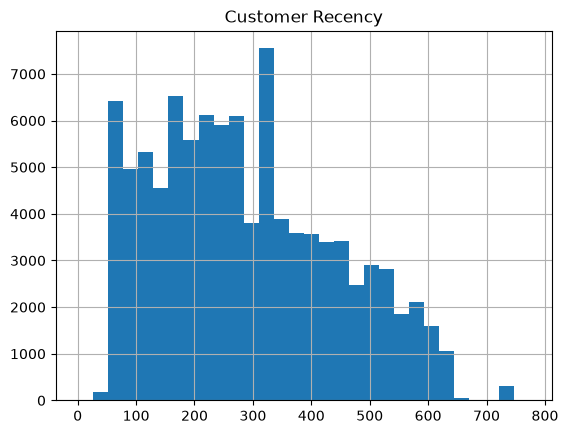

In [79]:
import matplotlib.pyplot as plt

rfm["Recency"].hist(bins=30)

plt.title("Customer Recency")
plt.show()

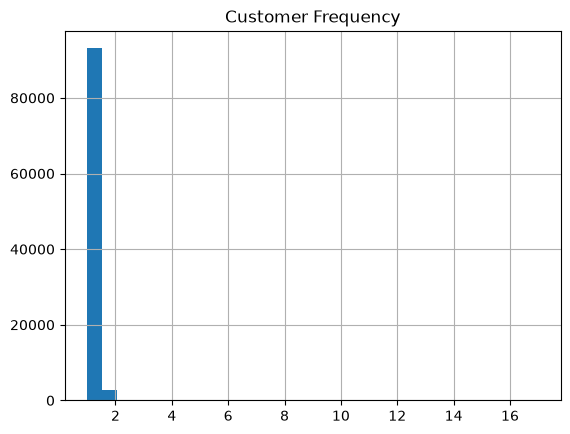

In [80]:
rfm["Frequency"].hist(bins=30)

plt.title("Customer Frequency")
plt.show()

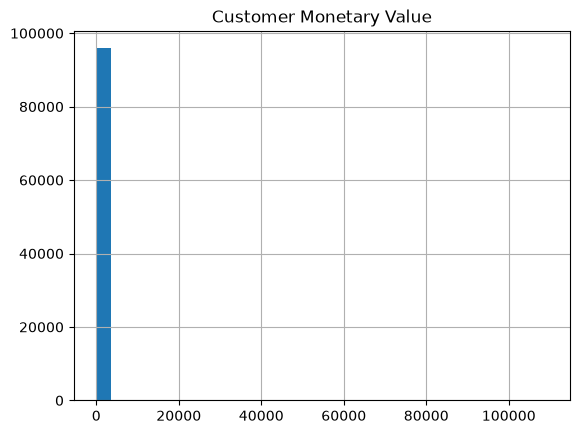

In [81]:
rfm["Monetary"].hist(bins=30)

plt.title("Customer Monetary Value")
plt.show()

In [86]:
master_df.to_csv("../data/master_df.csv", index=False)

In [87]:
import os

# Create the data folder if it doesn't exist
os.makedirs("data", exist_ok=True)

# Save the merged dataset
master_df.to_csv("data/master_df.csv", index=False)

print("master_df.csv saved successfully!")

master_df.csv saved successfully!
